<a href="https://colab.research.google.com/github/rakesh-sengupta/attribute-weighted-curvature/blob/main/attribute_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install dependencies (quiet). Safe to re-run.
import sys, subprocess
def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install([
    "numpy", "scipy", "pandas", "matplotlib", "seaborn",
    "statsmodels", "networkx", "GraphRicciCurvature", "tqdm", "nbformat"
])
print("Dependencies installed.")

Dependencies installed.


In [ ]:
import os, warnings, json, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from tqdm.auto import tqdm
from GraphRicciCurvature.FormanRicci import FormanRicci

warnings.filterwarnings("ignore")
np.random.seed(20260419)

# --- Publication-style matplotlib defaults ---
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
    "lines.linewidth": 1.6,
})
sns.set_palette("colorblind")

# Output directories
ROOT = Path("/content") if Path("/content").exists() else Path(".")
FIG_DIR = ROOT / "figs"
TAB_DIR = ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    print(f"  saved: {FIG_DIR / name}.(pdf|png)")

def save_table(df, name):
    df.to_csv(TAB_DIR / f"{name}.csv", index=False)
    print(f"  saved: {TAB_DIR / name}.csv")

print("Setup complete.")


Setup complete.


In [ ]:
def simulate_network(n_nodes, rho_attr, beta_A, beta_B, intercept, rng):
    """Simulate a network with two correlated node attributes driving homophily.

    Returns
    -------
    G : networkx.Graph with node attributes 'A' and 'B'
    dyads : DataFrame with columns [i, j, dA, dB, edge]
    """
    cov = np.array([[1.0, rho_attr], [rho_attr, 1.0]])
    attrs = rng.multivariate_normal(mean=[0.0, 0.0], cov=cov, size=n_nodes)
    A, B = attrs[:, 0], attrs[:, 1]

    ii, jj = np.triu_indices(n_nodes, k=1)
    dA = np.abs(A[ii] - A[jj])
    dB = np.abs(B[ii] - B[jj])
    logits = intercept - beta_A * dA - beta_B * dB
    probs = 1.0 / (1.0 + np.exp(-logits))
    edges = rng.binomial(1, probs).astype(int)

    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    for k in np.where(edges == 1)[0]:
        G.add_edge(int(ii[k]), int(jj[k]))
    for node in G.nodes():
        G.nodes[node]["A"] = float(A[node])
        G.nodes[node]["B"] = float(B[node])

    dyads = pd.DataFrame({"i": ii, "j": jj, "dA": dA, "dB": dB, "edge": edges})
    return G, dyads


def fit_homophily_models(dyads):
    """Fit misspecified (A-only) and correctly specified (A,B) logistic ERGMs.

    Note: we use NEGATIVE distance so a positive coefficient encodes homophily.
    """
    y = dyads["edge"].values
    X1 = sm.add_constant(-dyads[["dA"]].values)
    X2 = sm.add_constant(-dyads[["dA", "dB"]].values)

    out = {"beta_A_mis": np.nan, "se_A_mis": np.nan,
           "beta_A_cor": np.nan, "se_A_cor": np.nan,
           "beta_B_cor": np.nan, "se_B_cor": np.nan}
    try:
        m1 = sm.Logit(y, X1).fit(disp=0, method="lbfgs", maxiter=200)
        out["beta_A_mis"] = m1.params[1]
        out["se_A_mis"]   = m1.bse[1]
    except Exception:
        pass
    try:
        m2 = sm.Logit(y, X2).fit(disp=0, method="lbfgs", maxiter=200)
        out["beta_A_cor"] = m2.params[1]
        out["se_A_cor"]   = m2.bse[1]
        out["beta_B_cor"] = m2.params[2]
        out["se_B_cor"]   = m2.bse[2]
    except Exception:
        pass
    return out


def forman_curvature_edges(G):
    """Return a DataFrame of edges with Forman-Ricci curvature and attribute distances.

    Uses augmented Forman-Ricci from GraphRicciCurvature. Isolated nodes are fine.
    """
    if G.number_of_edges() == 0:
        return pd.DataFrame(columns=["u", "v", "formanCurvature", "dA", "dB"])
    H = G.copy()
    fr = FormanRicci(H, verbose="ERROR")
    fr.compute_ricci_curvature()
    rows = []
    for u, v, d in fr.G.edges(data=True):
        a_u, a_v = fr.G.nodes[u]["A"], fr.G.nodes[v]["A"]
        b_u, b_v = fr.G.nodes[u]["B"], fr.G.nodes[v]["B"]
        rows.append({
            "u": u, "v": v,
            "formanCurvature": d.get("formanCurvature", np.nan),
            "dA": abs(a_u - a_v),
            "dB": abs(b_u - b_v),
        })
    return pd.DataFrame(rows)


In [ ]:
# --- Study 1 configuration ---
S1_N_REPS      = 300
S1_RHO_GRID    = [0.0, 0.2, 0.4, 0.6, 0.8]
S1_N_GRID      = [40, 80, 150]
S1_BETA_A_TRUE = 1.2
S1_BETA_B_TRUE = 1.2
S1_INTERCEPT   = -1.0  # targets ~20-30% density regime

rng_master = np.random.default_rng(seed=7)

study1_records = []
combos = list(itertools.product(S1_RHO_GRID, S1_N_GRID))
for rho, n in tqdm(combos, desc="Study 1 grid"):
    for rep in range(S1_N_REPS):
        rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
        G, dyads = simulate_network(
            n_nodes=n, rho_attr=rho,
            beta_A=S1_BETA_A_TRUE, beta_B=S1_BETA_B_TRUE,
            intercept=S1_INTERCEPT, rng=rng,
        )
        density = dyads["edge"].mean()
        res = fit_homophily_models(dyads)
        study1_records.append({
            "rho": rho, "n": n, "rep": rep, "density": density,
            **res,
        })

s1 = pd.DataFrame(study1_records)
print(f"Study 1 complete: {len(s1)} rows")
s1.head()


Study 1 grid:   0%|          | 0/15 [00:00<?, ?it/s]

Study 1 complete: 4500 rows


,rho,n,rep,density,beta_A_mis,se_A_mis,beta_A_cor,se_A_cor,beta_B_cor,se_B_cor
0,0.0,40,0,0.067949,1.212665,0.275974,1.243095,0.275296,1.038975,0.295202
1,0.0,40,1,0.060256,1.396550,0.340431,1.368713,0.343657,1.126289,0.270309
2,0.0,40,2,0.067949,1.216052,0.253229,1.201591,0.255760,1.209705,0.332144
3,0.0,40,3,0.053846,0.962926,0.267491,1.009988,0.273431,0.956326,0.274797
4,0.0,40,4,0.053846,1.164089,0.309929,1.222391,0.316058,1.398195,0.329342


In [ ]:
# --- Study 1 summaries ---
s1["bias_mis"] = s1["beta_A_mis"] - S1_BETA_A_TRUE
s1["bias_cor"] = s1["beta_A_cor"] - S1_BETA_A_TRUE

# Wald 95% CI coverage
z = 1.959963984540054
s1["cov_mis"] = ((s1["beta_A_mis"] - z * s1["se_A_mis"] <= S1_BETA_A_TRUE) &
                 (s1["beta_A_mis"] + z * s1["se_A_mis"] >= S1_BETA_A_TRUE)).astype(int)
s1["cov_cor"] = ((s1["beta_A_cor"] - z * s1["se_A_cor"] <= S1_BETA_A_TRUE) &
                 (s1["beta_A_cor"] + z * s1["se_A_cor"] >= S1_BETA_A_TRUE)).astype(int)

summary1 = (s1.groupby(["rho", "n"], as_index=False)
              .agg(mean_bias_mis=("bias_mis", "mean"),
                   se_bias_mis=("bias_mis", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
                   mean_bias_cor=("bias_cor", "mean"),
                   mean_beta_A_mis=("beta_A_mis", "mean"),
                   coverage_mis=("cov_mis", "mean"),
                   coverage_cor=("cov_cor", "mean"),
                   density=("density", "mean")))
summary1 = summary1.round(4)
display(summary1)
save_table(summary1, "table1_study1_bias_coverage")


,rho,n,mean_bias_mis,se_bias_mis,mean_bias_cor,mean_beta_A_mis,coverage_mis,coverage_cor,density
0,0.0,40,0.0035,0.0179,0.0468,1.2035,0.9700,0.9833,0.0464
1,0.0,80,-0.0207,0.0097,0.0069,1.1793,0.9433,0.9467,0.0470
2,0.0,150,-0.0193,0.0046,0.0093,1.1807,0.9533,0.9600,0.0474
3,0.2,40,0.0319,0.0202,0.0513,1.2319,0.9500,0.9600,0.0465
4,0.2,80,-0.0020,0.0092,0.0151,1.1980,0.9500,0.9600,0.0474
5,0.2,150,-0.0150,0.0050,-0.0005,1.1850,0.9400,0.9500,0.0476
6,0.4,40,0.0970,0.0197,0.0704,1.2970,0.9567,0.9667,0.0484
7,0.4,80,0.0460,0.0098,0.0134,1.2460,0.9400,0.9367,0.0491
8,0.4,150,0.0355,0.0052,-0.0013,1.2355,0.9333,0.9367,0.0494
9,0.6,40,0.2017,0.0198,0.0628,1.4017,0.9400,0.9433,0.0518


  saved: /content/tables/table1_study1_bias_coverage.csv


  saved: /content/figs/fig1_study1_bias_surface.(pdf|png)


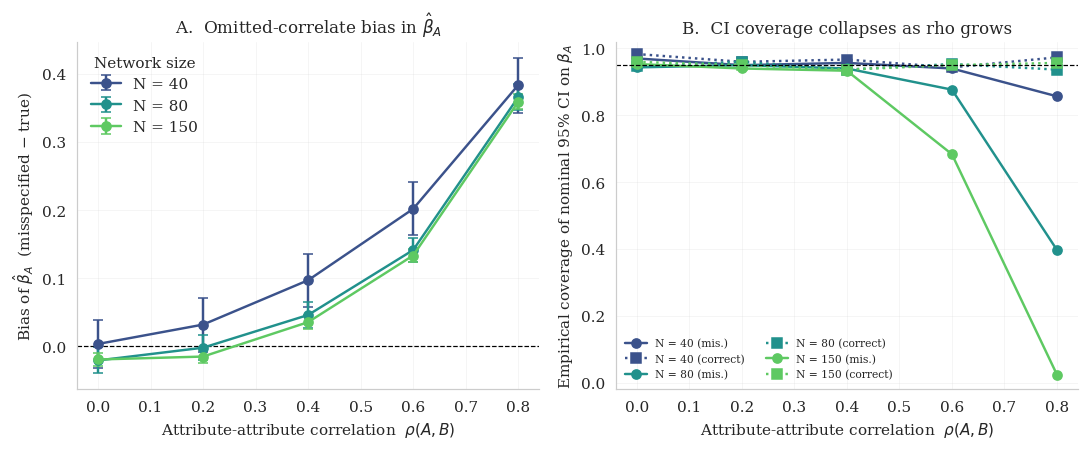

In [ ]:
# --- Figure 1: bias surface & coverage ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# Panel A: bias of beta_A (misspecified) vs rho, lines = N
ax = axes[0]
palette = sns.color_palette("viridis", len(S1_N_GRID))
for k, n in enumerate(S1_N_GRID):
    sub = summary1[summary1["n"] == n].sort_values("rho")
    ax.errorbar(sub["rho"], sub["mean_bias_mis"], yerr=1.96 * sub["se_bias_mis"],
                marker="o", color=palette[k], label=f"N = {n}", capsize=3)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"Attribute-attribute correlation  $\rho(A,B)$")
ax.set_ylabel(r"Bias of $\hat{\beta}_A$  (misspecified $-$ true)")
ax.set_title(r"A.  Omitted-correlate bias in $\hat{\beta}_A$")
ax.legend(title="Network size")

# Panel B: coverage of 95% CI
ax = axes[1]
for k, n in enumerate(S1_N_GRID):
    sub = summary1[summary1["n"] == n].sort_values("rho")
    ax.plot(sub["rho"], sub["coverage_mis"], marker="o", color=palette[k],
            label=f"N = {n} (mis.)", ls="-")
    ax.plot(sub["rho"], sub["coverage_cor"], marker="s", color=palette[k],
            label=f"N = {n} (correct)", ls=":")
ax.axhline(0.95, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"Attribute-attribute correlation  $\rho(A,B)$")
ax.set_ylabel(r"Empirical coverage of nominal 95% CI on $\beta_A$")
ax.set_title("B.  CI coverage collapses as rho grows")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower left", fontsize=7, ncol=2)

#fig.suptitle("Figure 1.  Omitted correlated attribute biases homophily estimates", y=1.02)
plt.tight_layout()
save_fig(fig, "fig1_study1_bias_surface")
plt.show()


In [ ]:
# --- Study 2 configuration ---
S2_N_REPS    = 120
S2_RHO_GRID  = [0.0, 0.2, 0.4, 0.6, 0.8]
S2_N_NODES   = 80
S2_BETA_A    = 1.2
S2_BETA_B    = 1.2
S2_INTERCEPT = -1.0

rng_master = np.random.default_rng(seed=11)
study2_records = []

for rho in tqdm(S2_RHO_GRID, desc="Study 2 rho"):
    for rep in range(S2_N_REPS):
        rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
        G, dyads = simulate_network(
            n_nodes=S2_N_NODES, rho_attr=rho,
            beta_A=S2_BETA_A, beta_B=S2_BETA_B,
            intercept=S2_INTERCEPT, rng=rng,
        )
        edf = forman_curvature_edges(G)
        if len(edf) < 10:
            continue
        y = edf["formanCurvature"].values
        X1 = sm.add_constant(-edf[["dA"]].values)
        X2 = sm.add_constant(-edf[["dA", "dB"]].values)
        try:
            m1 = sm.OLS(y, X1).fit()
            m2 = sm.OLS(y, X2).fit()
            study2_records.append({
                "rho": rho, "rep": rep, "n_edges": len(edf),
                "mean_curv": y.mean(), "sd_curv": y.std(ddof=1),
                "betaA_curv_mis": m1.params[1], "seA_curv_mis": m1.bse[1],
                "betaA_curv_cor": m2.params[1], "seA_curv_cor": m2.bse[1],
                "betaB_curv_cor": m2.params[2],
            })
        except Exception:
            continue

s2 = pd.DataFrame(study2_records)
print(f"Study 2 complete: {len(s2)} rows")
s2.head()


Study 2 rho:   0%|          | 0/5 [00:00<?, ?it/s]

Study 2 complete: 600 rows


,rho,rep,n_edges,mean_curv,sd_curv,betaA_curv_mis,seA_curv_mis,betaA_curv_cor,seA_curv_cor,betaB_curv_cor
0,0.0,0,157,-5.840764,3.169384,-0.255382,0.506234,-0.295304,0.513553,0.256204
1,0.0,1,130,-3.738462,2.351163,0.094499,0.399244,0.119696,0.412222,0.087804
2,0.0,2,149,-5.087248,3.103905,-0.837580,0.435238,-0.855150,0.441886,-0.137177
3,0.0,3,130,-4.153846,2.222023,-0.052846,0.318212,0.031581,0.324092,-0.485220
4,0.0,4,115,-3.626087,2.198328,0.558969,0.381311,0.542472,0.383860,-0.219550


In [ ]:
# --- Study 2 summary ---
summary2 = (s2.groupby("rho", as_index=False)
              .agg(n_reps=("rep", "count"),
                   mean_betaA_curv_mis=("betaA_curv_mis", "mean"),
                   se_betaA_curv_mis=("betaA_curv_mis",
                                      lambda x: x.std(ddof=1) / np.sqrt(len(x))),
                   mean_betaA_curv_cor=("betaA_curv_cor", "mean"),
                   se_betaA_curv_cor=("betaA_curv_cor",
                                      lambda x: x.std(ddof=1) / np.sqrt(len(x))),
                   mean_betaB_curv_cor=("betaB_curv_cor", "mean"),
                   mean_edges=("n_edges", "mean"),
                   mean_curv=("mean_curv", "mean")))
summary2 = summary2.round(4)
display(summary2)
save_table(summary2, "table2_study2_curvature_inheritance")


,rho,n_reps,mean_betaA_curv_mis,se_betaA_curv_mis,mean_betaA_curv_cor,se_betaA_curv_cor,mean_betaB_curv_cor,mean_edges,mean_curv
0,0.0,120,-0.2408,0.0508,-0.2492,0.0510,-0.2547,149.0750,-5.2745
1,0.2,120,-0.3974,0.0456,-0.3982,0.0457,-0.3151,148.9083,-5.3068
2,0.4,120,-0.2495,0.0485,-0.2501,0.0485,-0.3012,154.1250,-5.4794
3,0.6,120,-0.2213,0.0485,-0.2084,0.0489,-0.2400,163.1417,-5.7656
4,0.8,120,-0.1534,0.0526,-0.1225,0.0534,-0.1702,180.9333,-6.4335


  saved: /content/tables/table2_study2_curvature_inheritance.csv


  saved: /content/figs/fig2_study2_curvature_inheritance.(pdf|png)


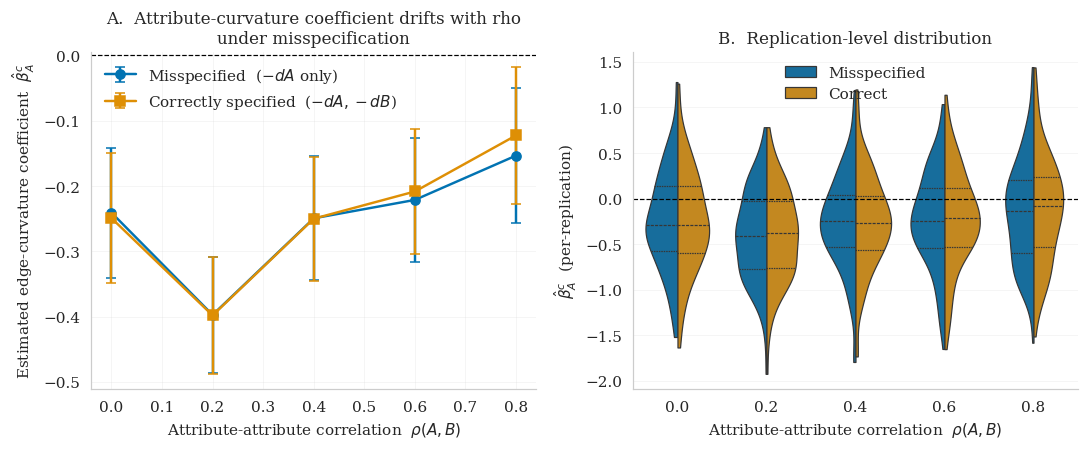

In [ ]:
# --- Figure 2: curvature-association bias ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# Panel A: mean betaA_curv (mis vs cor) across rho
ax = axes[0]
sub = summary2.sort_values("rho")
ax.errorbar(sub["rho"], sub["mean_betaA_curv_mis"],
            yerr=1.96 * sub["se_betaA_curv_mis"],
            marker="o", label=r"Misspecified  ($-dA$ only)", capsize=3)
ax.errorbar(sub["rho"], sub["mean_betaA_curv_cor"],
            yerr=1.96 * sub["se_betaA_curv_cor"],
            marker="s", label=r"Correctly specified  ($-dA, -dB$)", capsize=3)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"Attribute-attribute correlation  $\rho(A,B)$")
ax.set_ylabel(r"Estimated edge-curvature coefficient  $\hat{\beta}_A^c$")
ax.set_title("A.  Attribute-curvature coefficient drifts with rho\nunder misspecification")
ax.legend()

# Panel B: replication-level distribution of betaA_curv, by rho
ax = axes[1]
long2 = pd.concat([
    s2.assign(model="Misspecified").rename(columns={"betaA_curv_mis": "betaA_curv"})[["rho", "betaA_curv", "model"]],
    s2.assign(model="Correct").rename(columns={"betaA_curv_cor": "betaA_curv"})[["rho", "betaA_curv", "model"]],
])
sns.violinplot(data=long2, x="rho", y="betaA_curv", hue="model",
               split=True, inner="quartile", ax=ax, cut=0, linewidth=0.8)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"Attribute-attribute correlation  $\rho(A,B)$")
ax.set_ylabel(r"$\hat{\beta}_A^c$  (per-replication)")
ax.set_title("B.  Replication-level distribution")
ax.legend(title="")

#fig.suptitle("Figure 2.  Bias propagates from homophily inference into curvature-attribute association",
#             y=1.03)
plt.tight_layout()
save_fig(fig, "fig2_study2_curvature_inheritance")
plt.show()


In [ ]:
# --- Study 3 configuration ---
S3_N_REPS   = 300
S3_N_NODES  = 80
S3_DENSITY  = 0.15   # independent Bernoulli edges; NO homophily
S3_RHO_ATTR = 0.5    # attributes correlated but do NOT drive edges
S3_N_PERMS  = 200
ALPHA       = 0.05

rng_master = np.random.default_rng(seed=17)
study3_records = []

for rep in tqdm(range(S3_N_REPS), desc="Study 3 null sims"):
    rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
    n = S3_N_NODES

    # Correlated attrs, independent of graph
    cov = np.array([[1.0, S3_RHO_ATTR], [S3_RHO_ATTR, 1.0]])
    attrs = rng.multivariate_normal([0, 0], cov, size=n)
    A, B = attrs[:, 0], attrs[:, 1]

    # Random graph: independent Bernoulli edges, NO attribute effect
    ii, jj = np.triu_indices(n, k=1)
    edges = rng.binomial(1, S3_DENSITY, size=len(ii))
    G = nx.Graph(); G.add_nodes_from(range(n))
    for k in np.where(edges == 1)[0]:
        G.add_edge(int(ii[k]), int(jj[k]))
    for v in G.nodes():
        G.nodes[v]["A"] = float(A[v]); G.nodes[v]["B"] = float(B[v])

    edf = forman_curvature_edges(G)
    if len(edf) < 20:
        continue

    # Naive OLS: edge-level t-test on slope of curvature ~ -dA
    y = edf["formanCurvature"].values
    X = sm.add_constant(-edf[["dA"]].values)
    m = sm.OLS(y, X).fit()
    naive_p = m.pvalues[1]
    obs_slope = m.params[1]

    # Node-permutation: shuffle A across nodes; recompute dA for existing edges
    u_idx = edf["u"].values; v_idx = edf["v"].values
    perm_slopes = np.empty(S3_N_PERMS)
    for p in range(S3_N_PERMS):
        A_perm = rng.permutation(A)
        dA_perm = np.abs(A_perm[u_idx] - A_perm[v_idx])
        # Closed-form OLS slope (faster than full fit)
        x = -dA_perm
        xc = x - x.mean()
        yc = y - y.mean()
        denom = (xc ** 2).sum()
        perm_slopes[p] = (xc * yc).sum() / denom if denom > 0 else 0.0
    perm_p = (np.sum(np.abs(perm_slopes) >= np.abs(obs_slope)) + 1) / (S3_N_PERMS + 1)

    study3_records.append({
        "rep": rep, "n_edges": len(edf),
        "naive_p": naive_p, "perm_p": perm_p,
        "obs_slope": obs_slope,
    })

s3 = pd.DataFrame(study3_records)
print(f"Study 3 complete: {len(s3)} rows")

# Type I rates with Wilson 95% CI
def wilson(k, n, z=1.96):
    p = k / n
    denom = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return centre - half, centre + half

n3 = len(s3)
naive_rate = (s3["naive_p"] < ALPHA).mean()
perm_rate  = (s3["perm_p"]  < ALPHA).mean()
naive_lo, naive_hi = wilson((s3["naive_p"] < ALPHA).sum(), n3)
perm_lo,  perm_hi  = wilson((s3["perm_p"]  < ALPHA).sum(),  n3)

table3 = pd.DataFrame({
    "procedure":     ["Naive OLS (edge-level t-test)", "Node-permutation"],
    "type_I_rate":   [naive_rate, perm_rate],
    "ci_lower_95":   [naive_lo, perm_lo],
    "ci_upper_95":   [naive_hi, perm_hi],
    "n_simulations": [n3, n3],
    "nominal_alpha": [ALPHA, ALPHA],
}).round(4)
display(table3)
save_table(table3, "table3_study3_type1_rates")


Study 3 null sims:   0%|          | 0/300 [00:00<?, ?it/s]

Study 3 complete: 300 rows


,procedure,type_I_rate,ci_lower_95,ci_upper_95,n_simulations,nominal_alpha
0,Naive OLS (edge-level t-test),0.18,0.1407,0.2274,300,0.05
1,Node-permutation,0.08,0.0543,0.1163,300,0.05


  saved: /content/tables/table3_study3_type1_rates.csv


  saved: /content/figs/fig3_study3_type1_inflation.(pdf|png)


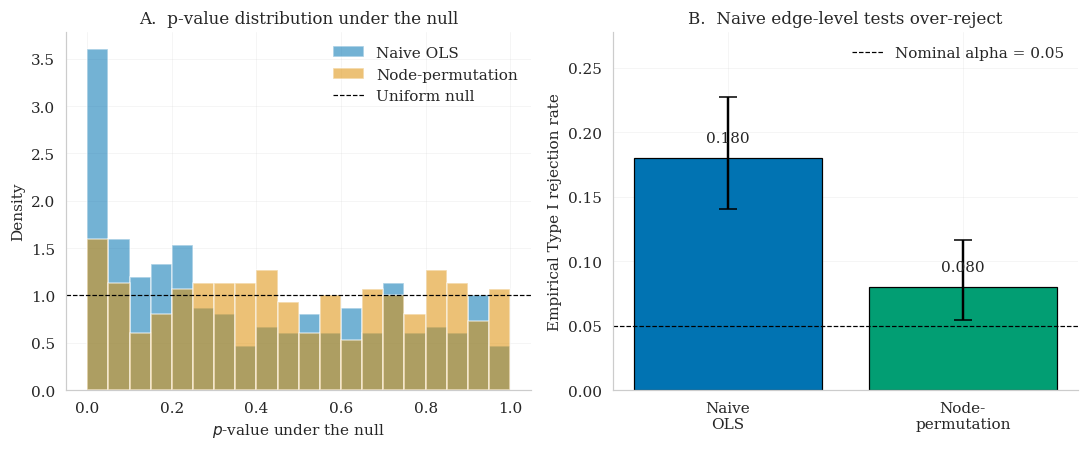

In [ ]:
# --- Figure 3: Type I inflation ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# Panel A: p-value distribution comparison
ax = axes[0]
bins = np.linspace(0, 1, 21)
ax.hist(s3["naive_p"], bins=bins, alpha=0.55, label="Naive OLS", density=True)
ax.hist(s3["perm_p"],  bins=bins, alpha=0.55, label="Node-permutation", density=True)
ax.axhline(1.0, color="black", lw=0.8, ls="--", label="Uniform null")
ax.set_xlabel(r"$p$-value under the null")
ax.set_ylabel("Density")
ax.set_title("A.  p-value distribution under the null")
ax.legend()

# Panel B: Type I rate bar with Wilson CIs
ax = axes[1]
procs  = ["Naive\nOLS", "Node-\npermutation"]
rates  = [naive_rate, perm_rate]
lowers = [naive_lo,   perm_lo]
uppers = [naive_hi,   perm_hi]
errs = np.array([[r - lo for r, lo in zip(rates, lowers)],
                 [up - r for r, up in zip(rates, uppers)]])
bars = ax.bar(procs, rates, yerr=errs, capsize=6,
              color=[sns.color_palette()[0], sns.color_palette()[2]],
              edgecolor="black", linewidth=0.8)
ax.axhline(ALPHA, color="black", lw=0.8, ls="--", label=f"Nominal alpha = {ALPHA}")
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.01, f"{r:.3f}",
            ha="center", va="bottom")
ax.set_ylabel("Empirical Type I rejection rate")
ax.set_title("B.  Naive edge-level tests over-reject")
ax.set_ylim(0, max(0.25, max(uppers) + 0.05))
ax.legend()

#fig.suptitle("Figure 3.  Edge-level non-independence inflates Type I for curvature-attribute tests",
#             y=1.03)
plt.tight_layout()
save_fig(fig, "fig3_study3_type1_inflation")
plt.show()


In [ ]:
combined_rows = []

# Study 1: pick N = 80 as representative
for rho in S1_RHO_GRID:
    sub = summary1[(summary1["n"] == 80) & (summary1["rho"] == rho)].iloc[0]
    combined_rows.append({
        "study": "1 - Homophily bias",
        "rho": rho,
        "metric": "Bias of beta_A_hat (misspecified)",
        "value": float(sub["mean_bias_mis"]),
        "notes": f"N=80, true beta_A={S1_BETA_A_TRUE}, coverage={sub['coverage_mis']:.2f}",
    })

for rho in S2_RHO_GRID:
    sub = summary2[summary2["rho"] == rho].iloc[0]
    combined_rows.append({
        "study": "2 - Curvature inheritance",
        "rho": rho,
        "metric": "beta_A^c diff (misspecified - correct)",
        "value": float(sub["mean_betaA_curv_mis"] - sub["mean_betaA_curv_cor"]),
        "notes": f"Forman-Ricci, N={S2_N_NODES}",
    })

combined_rows.append({
    "study": "3 - Type I inflation",
    "rho": "-",
    "metric": "Type I rate, naive OLS",
    "value": float(naive_rate),
    "notes": f"null DGP; alpha={ALPHA}; 95% CI [{naive_lo:.3f}, {naive_hi:.3f}]",
})
combined_rows.append({
    "study": "3 - Type I inflation",
    "rho": "-",
    "metric": "Type I rate, node-permutation",
    "value": float(perm_rate),
    "notes": f"null DGP; alpha={ALPHA}; 95% CI [{perm_lo:.3f}, {perm_hi:.3f}]",
})

combined = pd.DataFrame(combined_rows)
combined["value"] = combined["value"].astype(float).round(4)
display(combined)
save_table(combined, "table_combined_headline")


,study,rho,metric,value,notes
0,1 - Homophily bias,0.0,Bias of beta_A_hat (misspecified),-0.0207,"N=80, true beta_A=1.2, coverage=0.94"
1,1 - Homophily bias,0.2,Bias of beta_A_hat (misspecified),-0.0020,"N=80, true beta_A=1.2, coverage=0.95"
2,1 - Homophily bias,0.4,Bias of beta_A_hat (misspecified),0.0460,"N=80, true beta_A=1.2, coverage=0.94"
3,1 - Homophily bias,0.6,Bias of beta_A_hat (misspecified),0.1413,"N=80, true beta_A=1.2, coverage=0.88"
4,1 - Homophily bias,0.8,Bias of beta_A_hat (misspecified),0.3656,"N=80, true beta_A=1.2, coverage=0.40"
5,2 - Curvature inheritance,0.0,beta_A^c diff (misspecified - correct),0.0084,"Forman-Ricci, N=80"
6,2 - Curvature inheritance,0.2,beta_A^c diff (misspecified - correct),0.0008,"Forman-Ricci, N=80"
7,2 - Curvature inheritance,0.4,beta_A^c diff (misspecified - correct),0.0006,"Forman-Ricci, N=80"
8,2 - Curvature inheritance,0.6,beta_A^c diff (misspecified - correct),-0.0129,"Forman-Ricci, N=80"
9,2 - Curvature inheritance,0.8,beta_A^c diff (misspecified - correct),-0.0309,"Forman-Ricci, N=80"


  saved: /content/tables/table_combined_headline.csv


In [ ]:
import os, warnings, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from tqdm.auto import tqdm
from GraphRicciCurvature.OllivierRicci import OllivierRicci

warnings.filterwarnings("ignore")
np.random.seed(20260419)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
    "axes.labelsize": 10, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "legend.frameon": False, "lines.linewidth": 1.6,
})
sns.set_palette("colorblind")

ROOT = Path("/content") if Path("/content").exists() else Path(".")
FIG_DIR = ROOT / "figs"
TAB_DIR = ROOT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    print(f"  saved: {FIG_DIR / name}.(pdf|png)")

def save_table(df, name):
    df.to_csv(TAB_DIR / f"{name}.csv", index=False)
    print(f"  saved: {TAB_DIR / name}.csv")

print("Setup complete.")

Setup complete.


In [ ]:
def simulate_network(n_nodes, rho_attr, beta_A, beta_B, intercept, rng):
    """Same DGP as Studies 1-3: correlated-attribute homophily."""
    cov = np.array([[1.0, rho_attr], [rho_attr, 1.0]])
    attrs = rng.multivariate_normal([0.0, 0.0], cov, size=n_nodes)
    A, B = attrs[:, 0], attrs[:, 1]
    ii, jj = np.triu_indices(n_nodes, k=1)
    dA = np.abs(A[ii] - A[jj])
    dB = np.abs(B[ii] - B[jj])
    logits = intercept - beta_A * dA - beta_B * dB
    probs = 1.0 / (1.0 + np.exp(-logits))
    edges = rng.binomial(1, probs).astype(int)
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    for k in np.where(edges == 1)[0]:
        G.add_edge(int(ii[k]), int(jj[k]))
    for v in G.nodes():
        G.nodes[v]["A"] = float(A[v])
        G.nodes[v]["B"] = float(B[v])
    return G


def assign_edge_weights(G, scheme):
    """In-place assignment of edge 'weight' attribute.

    scheme : one of 'unit', 'A_only', 'AB_joint'
    """
    for u, v, d in G.edges(data=True):
        Au, Av = G.nodes[u]["A"], G.nodes[v]["A"]
        Bu, Bv = G.nodes[u]["B"], G.nodes[v]["B"]
        if scheme == "unit":
            d["weight"] = 1.0
        elif scheme == "A_only":
            d["weight"] = 1.0 + abs(Au - Av)
        elif scheme == "AB_joint":
            d["weight"] = 1.0 + np.sqrt((Au - Av) ** 2 + (Bu - Bv) ** 2)
        else:
            raise ValueError(scheme)
    return G


def ollivier_curvature_by_scheme(G, scheme, alpha=0.5):
    """Assign weights under scheme, run Ollivier-Ricci, return dict{(u,v): kappa}."""
    if G.number_of_edges() == 0:
        return {}
    H = G.copy()
    assign_edge_weights(H, scheme)
    orc = OllivierRicci(H, alpha=alpha, weight="weight", verbose="ERROR")
    orc.compute_ricci_curvature()
    out = {}
    for u, v, d in orc.G.edges(data=True):
        key = (min(u, v), max(u, v))
        out[key] = d.get("ricciCurvature", np.nan)
    return out


def edge_attribute_distances(G):
    """Dict {(u,v): (dA, dB)} for each edge."""
    out = {}
    for u, v in G.edges():
        Au, Av = G.nodes[u]["A"], G.nodes[v]["A"]
        Bu, Bv = G.nodes[u]["B"], G.nodes[v]["B"]
        key = (min(u, v), max(u, v))
        out[key] = (abs(Au - Av), abs(Bu - Bv))
    return out

print("Simulation and weighting functions loaded.")

Simulation and weighting functions loaded.


In [ ]:
# --- Study 2b configuration ---
S2B_N_REPS     = 30
S2B_RHO_GRID   = [0.0, 0.2, 0.4, 0.6, 0.8]
S2B_N_NODES    = 60
S2B_BETA_A     = 1.2
S2B_BETA_B     = 1.2
S2B_INTERCEPT  = -1.0

rng_master = np.random.default_rng(seed=23)

edge_records = []
rep_records = []

total_iters = len(S2B_RHO_GRID) * S2B_N_REPS
pbar = tqdm(total=total_iters, desc="Study 2b")
for rho in S2B_RHO_GRID:
    for rep in range(S2B_N_REPS):
        rng = np.random.default_rng(rng_master.integers(0, 2 ** 32 - 1))
        G = simulate_network(
            n_nodes=S2B_N_NODES, rho_attr=rho,
            beta_A=S2B_BETA_A, beta_B=S2B_BETA_B,
            intercept=S2B_INTERCEPT, rng=rng,
        )
        if G.number_of_edges() < 20:
            pbar.update(1); continue

        # Compute all three curvatures on the same graph
        curv_unit = ollivier_curvature_by_scheme(G, "unit")
        curv_A    = ollivier_curvature_by_scheme(G, "A_only")
        curv_AB   = ollivier_curvature_by_scheme(G, "AB_joint")
        dist_map  = edge_attribute_distances(G)

        # Collect per-edge records
        for key, (dA, dB) in dist_map.items():
            edge_records.append({
                "rho": rho, "rep": rep, "u": key[0], "v": key[1],
                "dA": dA, "dB": dB,
                "curv_unit": curv_unit.get(key, np.nan),
                "curv_A":    curv_A.get(key, np.nan),
                "curv_AB":   curv_AB.get(key, np.nan),
            })

        # Per-replication summary
        rep_records.append({
            "rho": rho, "rep": rep, "n_edges": len(dist_map),
            "mean_curv_unit": np.nanmean(list(curv_unit.values())),
            "mean_curv_A":    np.nanmean(list(curv_A.values())),
            "mean_curv_AB":   np.nanmean(list(curv_AB.values())),
            "sd_curv_unit":   np.nanstd(list(curv_unit.values()), ddof=1),
            "sd_curv_A":      np.nanstd(list(curv_A.values()), ddof=1),
            "sd_curv_AB":     np.nanstd(list(curv_AB.values()), ddof=1),
        })
        pbar.update(1)
pbar.close()

edge_df = pd.DataFrame(edge_records).dropna(subset=["curv_unit", "curv_A", "curv_AB"])
rep_df  = pd.DataFrame(rep_records)
print(f"\n{len(edge_df):,} edges kept across {len(rep_df)} replications.")
rep_df.head()

Study 2b:   0%|          | 0/150 [00:00<?, ?it/s]


13,412 edges kept across 150 replications.


,rho,rep,n_edges,mean_curv_unit,mean_curv_A,mean_curv_AB,sd_curv_unit,sd_curv_A,sd_curv_AB
0,0.0,0,66,-0.074747,-0.012974,0.028526,0.284038,0.305759,0.377961
1,0.0,1,102,-0.170717,-0.105630,-0.073402,0.177821,0.249691,0.343964
2,0.0,2,101,-0.174322,-0.112613,-0.107416,0.223522,0.255660,0.346850
3,0.0,3,95,-0.111067,-0.077628,-0.074145,0.228766,0.290758,0.333581
4,0.0,4,74,-0.100338,-0.028500,-0.015357,0.298332,0.366223,0.375340


In [ ]:
# --- Table 2b.1: curvature divergence across schemes ---
edge_df["delta_A_vs_AB"]   = edge_df["curv_A"] - edge_df["curv_AB"]
edge_df["delta_A_vs_unit"] = edge_df["curv_A"] - edge_df["curv_unit"]

divergence = (rep_df.groupby("rho")
                    .agg(n_reps=("rep", "count"),
                         mean_curv_unit=("mean_curv_unit", "mean"),
                         mean_curv_A=("mean_curv_A", "mean"),
                         mean_curv_AB=("mean_curv_AB", "mean"),
                         se_curv_A=("mean_curv_A",
                                    lambda x: x.std(ddof=1) / np.sqrt(len(x))),
                         se_curv_AB=("mean_curv_AB",
                                     lambda x: x.std(ddof=1) / np.sqrt(len(x))))
                    .reset_index())
divergence["gap_A_vs_AB"] = divergence["mean_curv_A"] - divergence["mean_curv_AB"]
divergence = divergence.round(4)
display(divergence)
save_table(divergence, "table_study2b_divergence")


# --- Table 2b.2: regression consequences by scheme ---
reg_rows = []
for rho in S2B_RHO_GRID:
    sub = edge_df[edge_df["rho"] == rho].dropna()
    if len(sub) < 30:
        continue
    for scheme, ycol in [("unit", "curv_unit"),
                         ("A_only", "curv_A"),
                         ("AB_joint", "curv_AB")]:
        y = sub[ycol].values
        X1 = sm.add_constant(-sub[["dA"]].values)
        X2 = sm.add_constant(-sub[["dA", "dB"]].values)
        try:
            m1 = sm.OLS(y, X1).fit()
            m2 = sm.OLS(y, X2).fit()
            reg_rows.append({
                "rho": rho, "scheme": scheme,
                "n_edges": len(sub),
                "betaA_mis": m1.params[1], "seA_mis": m1.bse[1],
                "betaA_cor": m2.params[1], "seA_cor": m2.bse[1],
                "betaB_cor": m2.params[2] if len(m2.params) > 2 else np.nan,
                "OVB_in_betaA": m1.params[1] - m2.params[1],
            })
        except Exception:
            pass
reg_df = pd.DataFrame(reg_rows).round(4)
display(reg_df)
save_table(reg_df, "table_study2b_regression_by_weighting")

,rho,n_reps,mean_curv_unit,mean_curv_A,mean_curv_AB,se_curv_A,se_curv_AB,gap_A_vs_AB
0,0.0,30,-0.1317,-0.0672,-0.0527,0.0087,0.0086,-0.0145
1,0.2,30,-0.1274,-0.0542,-0.0396,0.0065,0.0067,-0.0146
2,0.4,30,-0.1323,-0.0674,-0.0498,0.0073,0.0072,-0.0176
3,0.6,30,-0.1326,-0.0732,-0.0596,0.0058,0.0056,-0.0136
4,0.8,30,-0.1456,-0.0918,-0.0840,0.0059,0.0060,-0.0078


  saved: /content/tables/table_study2b_divergence.csv


,rho,scheme,n_edges,betaA_mis,seA_mis,betaA_cor,seA_cor,betaB_cor,OVB_in_betaA
0,0.0,unit,2519,-0.0264,0.0092,-0.0264,0.0092,-0.0014,0.0001
1,0.0,A_only,2519,0.1453,0.0112,0.1455,0.0112,0.0045,-0.0002
2,0.0,AB_joint,2519,0.1609,0.0133,0.1725,0.0126,0.2233,-0.0116
3,0.2,unit,2511,-0.0008,0.0099,-0.0017,0.0099,-0.0350,0.0009
4,0.2,A_only,2511,0.1891,0.0118,0.1884,0.0118,-0.0287,0.0007
5,0.2,AB_joint,2511,0.2055,0.0134,0.2099,0.0130,0.1725,-0.0044
6,0.4,unit,2600,-0.0054,0.0091,-0.0055,0.0090,-0.0304,0.0001
7,0.4,A_only,2600,0.1656,0.0113,0.1654,0.0113,-0.0338,0.0001
8,0.4,AB_joint,2600,0.1875,0.0127,0.1881,0.0124,0.1508,-0.0007
9,0.6,unit,2725,0.0072,0.0094,0.0071,0.0094,0.0025,0.0001


  saved: /content/tables/table_study2b_regression_by_weighting.csv


  saved: /content/figs/fig2b_2_regression_consequences.(pdf|png)


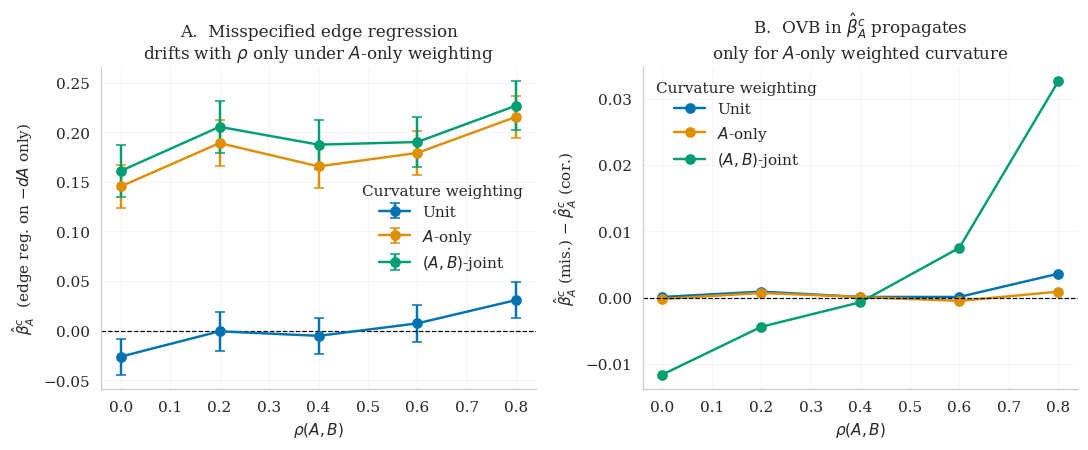

In [ ]:
# --- Figure 2b.2: regression-level consequences by scheme ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
palette = sns.color_palette("colorblind")
scheme_order  = ["unit", "A_only", "AB_joint"]
scheme_labels = {"unit": "Unit", "A_only": r"$A$-only", "AB_joint": r"$(A,B)$-joint"}
scheme_colors = {"unit": palette[0], "A_only": palette[1], "AB_joint": palette[2]}

# Panel A: misspecified edge regression coefficient, by scheme
ax = axes[0]
for scheme in scheme_order:
    sub = reg_df[reg_df["scheme"] == scheme].sort_values("rho")
    ax.errorbar(sub["rho"], sub["betaA_mis"], yerr=1.96 * sub["seA_mis"],
                marker="o", label=scheme_labels[scheme],
                color=scheme_colors[scheme], capsize=3)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"$\rho(A,B)$")
ax.set_ylabel(r"$\hat{\beta}_A^c$  (edge reg. on $-dA$ only)")
ax.set_title("A.  Misspecified edge regression\n"
             r"drifts with $\rho$ only under $A$-only weighting")
ax.legend(title="Curvature weighting")

# Panel B: OVB-in-metric diagnostic: betaA_mis - betaA_cor
ax = axes[1]
for scheme in scheme_order:
    sub = reg_df[reg_df["scheme"] == scheme].sort_values("rho")
    ax.plot(sub["rho"], sub["OVB_in_betaA"], marker="o",
            label=scheme_labels[scheme], color=scheme_colors[scheme])
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"$\rho(A,B)$")
ax.set_ylabel(r"$\hat{\beta}_A^c$ (mis.) $-$ $\hat{\beta}_A^c$ (cor.)")
ax.set_title(r"B.  OVB in $\hat{\beta}_A^c$ propagates"
             "\nonly for $A$-only weighted curvature")
ax.legend(title="Curvature weighting")

#fig.suptitle("Figure 2b.2.  Regression-level consequences of attribute-weighted curvature",
#             y=1.03)
plt.tight_layout()
save_fig(fig, "fig2b_2_regression_consequences")
plt.show()

  saved: /content/figs/fig2b_1_metric_choice_effect.(pdf|png)


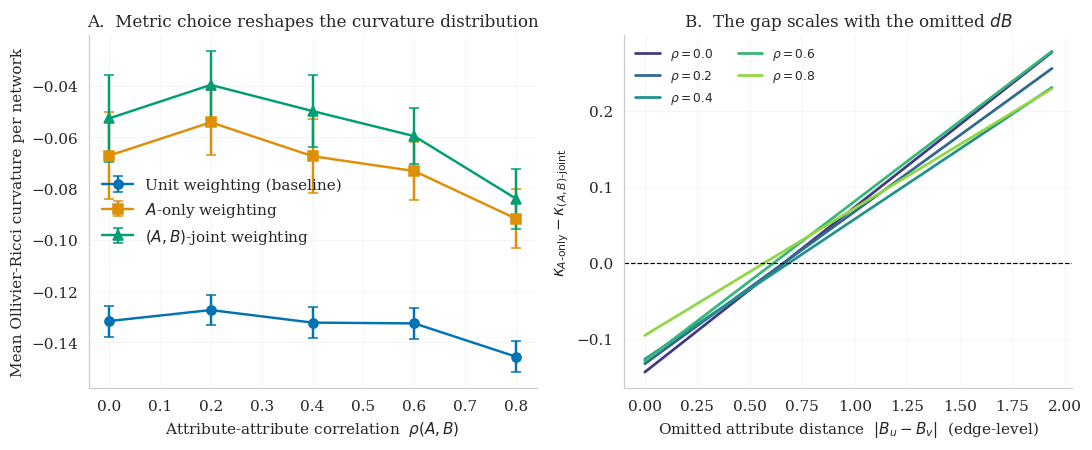

,rho,slope_delta_on_dB,se_slope,pvalue
0,0.0,0.2174,0.0081,0.0
1,0.2,0.2006,0.0077,0.0
2,0.4,0.1845,0.0075,0.0
3,0.6,0.2104,0.0077,0.0
4,0.8,0.1677,0.0070,0.0


  saved: /content/tables/table_study2b_delta_on_dB_slopes.csv


In [ ]:
# --- Figure 2b.1: mean curvature by scheme, and the dB signature ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

# Panel A: mean curvature per weighting scheme, across rho
ax = axes[0]
sub = divergence.sort_values("rho")
palette = sns.color_palette("colorblind")
ax.errorbar(sub["rho"], sub["mean_curv_unit"],
            yerr=1.96 * (sub["mean_curv_unit"].std(ddof=1) / np.sqrt(len(sub))),
            marker="o", color=palette[0], label="Unit weighting (baseline)",
            capsize=3)
ax.errorbar(sub["rho"], sub["mean_curv_A"],
            yerr=1.96 * sub["se_curv_A"],
            marker="s", color=palette[1], label=r"$A$-only weighting",
            capsize=3)
ax.errorbar(sub["rho"], sub["mean_curv_AB"],
            yerr=1.96 * sub["se_curv_AB"],
            marker="^", color=palette[2], label=r"$(A,B)$-joint weighting",
            capsize=3)
ax.set_xlabel(r"Attribute-attribute correlation  $\rho(A,B)$")
ax.set_ylabel("Mean Ollivier-Ricci curvature per network")
ax.set_title("A.  Metric choice reshapes the curvature distribution")
ax.legend()

# Panel B: per-edge regression of (delta = curv_A - curv_AB) on dB, by rho
ax = axes[1]
palette2 = sns.color_palette("viridis", len(S2B_RHO_GRID))
x_ref = np.linspace(0, edge_df["dB"].quantile(0.98), 50)
delta_slopes = []
for k, rho in enumerate(S2B_RHO_GRID):
    sub = edge_df[edge_df["rho"] == rho].dropna(subset=["delta_A_vs_AB", "dB"])
    if len(sub) < 30:
        continue
    X = sm.add_constant(sub["dB"].values)
    m = sm.OLS(sub["delta_A_vs_AB"].values, X).fit()
    y_ref = m.params[0] + m.params[1] * x_ref
    ax.plot(x_ref, y_ref, color=palette2[k], label=rf"$\rho = {rho}$",
            lw=1.8)
    delta_slopes.append({
        "rho": rho,
        "slope_delta_on_dB": m.params[1],
        "se_slope": m.bse[1],
        "pvalue": m.pvalues[1],
    })
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"Omitted attribute distance  $|B_u - B_v|$  (edge-level)")
ax.set_ylabel(r"$\kappa_{A\text{-only}} - \kappa_{(A,B)\text{-joint}}$")
ax.set_title(r"B.  The gap scales with the omitted $dB$")
ax.legend(title=None, fontsize=8, ncol=2)

#fig.suptitle("Figure 2b.1.  Attribute-in-metric bias: choosing which attributes to weight by matters",
#             y=1.03)
plt.tight_layout()
save_fig(fig, "fig2b_1_metric_choice_effect")
plt.show()

# Save the dB-slope diagnostic table
delta_slope_df = pd.DataFrame(delta_slopes).round(4)
display(delta_slope_df)
save_table(delta_slope_df, "table_study2b_delta_on_dB_slopes")